<a href="https://colab.research.google.com/github/timothy-shiwprasad/COMP6905_assigment_1/blob/main/Assigment_1_Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1: Golden-Section Search

$f(x) = x^4 + x^2 -3x + 2$

$Interval : -2 <= x <= 2$

# Question 1 A)

$f'(x) = 4x^3 + 2x -3$

$f''(x) = 12x^2 + 2$

Prove Convexity:

$x^2 >= 0 , for x ∈ ℝ$

$12x^2 >= 0$

$12x^2 + 2 >= 2 >= 0$
Hence : $f''(x) > 0 , for - all - x∈ℝ$

f(x) is convex.

Prove f(x) has a unique minimum on interval [-2,2]

f(x) is a polynomial ,and thus continous . [-2,2] is closed and bounded and by the Extreme Value Theorem , f(x) has a minimum within [-2,2] .

$f'(-2) = 4(-8) + 2(-2) -3 = -39  < 0$

$f'(2) = 4(8) + 2(2) -3 = 33 > 0 $

Since the Extreme Value theorem states there is a root present between [-2,2], f'(x) is strictly increasing and f is decreasing before it starts increasing. This also denotes that the function will reach a minimum before it starts increasing again. The minimizer is within the points[-2,2]. Since Golden search needs unimodality , f decreasing then increasing again. The algorthim is suitable for such problem as a minimum exists within the interval and minimum is unique.  





In [ ]:
# Question 1 C

import numpy as np


# Function we want to minimize
def polynomial(x):
    return x**4 + x**2 - 3*x + 2


def golden_section_search(f, a, b, tolerance):

    # Define the golden-ratio constant used to place the two
    # interior points within the current interval.
    golden_ratio = (np.sqrt(5) - 1) / 2

    # Initial interior points
    x_1 = b - golden_ratio * (b - a)
    x_2 = a + golden_ratio * (b - a)

    # Evaluate the function at the two interior points
    f_1 = f(x_1)
    f_2 = f(x_2)

    # Two function evaluations are needed initially
    evaluations = 2

    # Keep track of the intervals considered during the search
    intervals = [(a, b)]

    # Continue reducing the interval until its width is
    # smaller than the specified tolerance.
    while (b - a) >= tolerance:

        print(evaluations)
        print(intervals)

        # If f(x_1) > f(x_2), the minimum must lie to the
        # right of x_1, so we discard the interval [a, x_1].
        if f_1 > f_2:
            a = x_1

            # Reuse the previous x_2 and function evaluation
            x_1 = x_2
            f_1 = f_2

            # Calculate the new x_2
            x_2 = a + golden_ratio * (b - a)
            f_2 = f(x_2)

            evaluations += 1

        # Otherwise, the minimum must lie to the left of x_2,
        # so we discard the interval [x_2, b].
        else:
            b = x_2

            # Reuse the previous x_1 and function evaluation
            x_2 = x_1
            f_2 = f_1

            # Calculate the new x_1
            x_1 = b - golden_ratio * (b - a)
            f_1 = f(x_1)

            evaluations += 1

        # Store the new, smaller interval
        intervals.append((a, b))

        # Use the midpoint of the final interval as the estimated
        # location of the minimum.
        x_minimizer = (a + b) / 2

    return x_minimizer, f(x_minimizer), [a, b], evaluations, intervals

In [ ]:
minimizer,value,interval,evalautions,intervals = golden_section_search(polynomial,-2,2,10**-5)

2
[(-2, 2)]
3
[(-2, 2), (np.float64(-0.4721359549995796), 2)]
4
[(-2, 2), (np.float64(-0.4721359549995796), 2), (np.float64(-0.4721359549995796), np.float64(1.0557280900008412))]
5
[(-2, 2), (np.float64(-0.4721359549995796), 2), (np.float64(-0.4721359549995796), np.float64(1.0557280900008412)), (np.float64(0.11145618000168223), np.float64(1.0557280900008412))]
6
[(-2, 2), (np.float64(-0.4721359549995796), 2), (np.float64(-0.4721359549995796), np.float64(1.0557280900008412)), (np.float64(0.11145618000168223), np.float64(1.0557280900008412)), (np.float64(0.4721359549995796), np.float64(1.0557280900008412))]
7
[(-2, 2), (np.float64(-0.4721359549995796), 2), (np.float64(-0.4721359549995796), np.float64(1.0557280900008412)), (np.float64(0.11145618000168223), np.float64(1.0557280900008412)), (np.float64(0.4721359549995796), np.float64(1.0557280900008412)), (np.float64(0.4721359549995796), np.float64(0.8328157299974766))]
8
[(-2, 2), (np.float64(-0.4721359549995796), 2), (np.float64(-0.472135

In [ ]:
minimizer,value,interval,evalautions

(np.float64(0.728080355965536),
 np.float64(0.6268670120757274),
 [np.float64(0.7280758022729468), np.float64(0.7280849096581253)],
 29)

# Question 1 C

## Report
The minimizer: 0.72808035

The Coresponding function value: 0.62686

The Final Bracketing Interval: [0.7280,0.7280]

The Number of Evaluations: 29


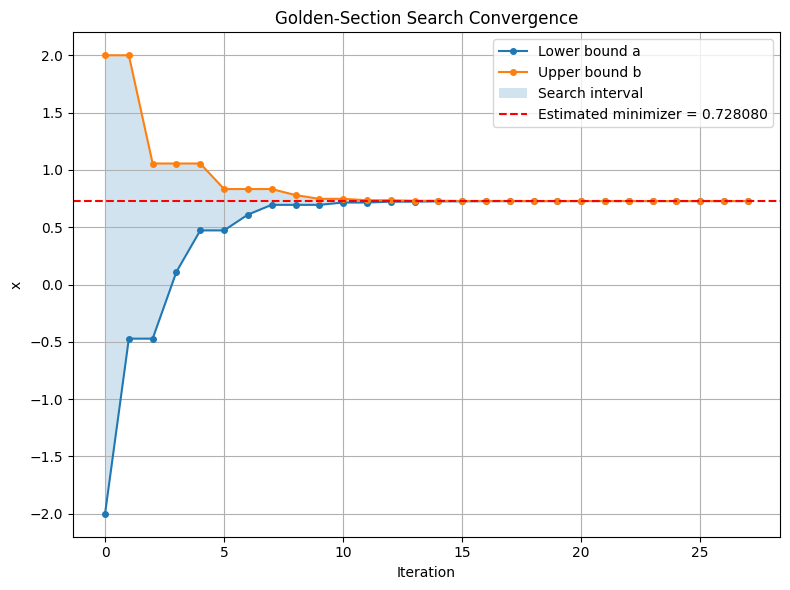

Final interval: [0.7280758022729468, 0.7280849096581253]
Estimated minimizer: x = 0.728080355965536
Estimated minimum value: f(x) = 0.6268670120757274


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Polynomial function
def f(x):
    return x**4 + x**2 - 3*x + 2


# Separate the lower and upper bounds
lower_bounds = np.array([a for a, b in intervals])
upper_bounds = np.array([b for a, b in intervals])

iterations = np.arange(len(intervals))


# Estimate the minimizer using the midpoint of the final interval
estimated_minimum_x = (
    lower_bounds[-1] + upper_bounds[-1]
) / 2

estimated_minimum_y = f(estimated_minimum_x)


# ----------------------------------------
# Golden-section interval convergence
# ----------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    iterations,
    lower_bounds,
    marker="o",
    markersize=4,
    label="Lower bound a"
)

plt.plot(
    iterations,
    upper_bounds,
    marker="o",
    markersize=4,
    label="Upper bound b"
)

# Shade the region between the lower and upper bounds
plt.fill_between(
    iterations,
    lower_bounds,
    upper_bounds,
    alpha=0.2,
    label="Search interval"
)

# Show the estimated minimizer
plt.axhline(
    estimated_minimum_x,
    color="red",
    linestyle="--",
    label=f"Estimated minimizer = {estimated_minimum_x:.6f}"
)

plt.xlabel("Iteration")
plt.ylabel("x")
plt.title("Golden-Section Search Convergence")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ----------------------------------------
# Display final numerical estimates
# ----------------------------------------

print(
    f"Final interval: "
    f"[{lower_bounds[-1]}, {upper_bounds[-1]}]"
)

print(
    f"Estimated minimizer: "
    f"x = {estimated_minimum_x}"
)

print(
    f"Estimated minimum value: "
    f"f(x) = {estimated_minimum_y}"
)